# 영화 추천 시스템

### ratings.csv
- 인기 영화 추천 : Popularity Recommendation Model
- 영화별 평점 갯수, 영화별 평균 평점 => 인기 영화 추천

### movies.csv
- 영화 장르 추천 : Content-Based Recommendation Model, Collaborative Recommendation Model
- 영화 장르 확인 및 변환(벡터화 하고 One-Hot Encoding)
  => 코사인 유사도(영화별 평점 갯수, 영화별 평균 평점을 참고)
  => 유사 영화 추천

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [4]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 3. 데이터 구조 확인

In [5]:
# 1. ratings, movies 구조 확인
print(ratings.shape)
print(movies.shape)

(100836, 4)
(10329, 3)


In [7]:
# 2. 컬럼 확인
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## 4. 결측치 & 중복 확인

In [12]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [14]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [16]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())  # subset : 이걸 준거로 중복 있는지 확인.

0


## 5. ratings + movies 데이터 병합

In [18]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     1.0     4.0  9.649827e+08  
1     5.0     4.0  8.474350e+08  
2     7.0     4.5  1.106636e+09  
3    15.0     2.5  1.510578e+09  
4    17.0     4.5  1.305696e+09  


## 6. 전체 평점 분포

In [23]:
ratings_count = ratings["rating"].value_counts().sort_index()  # sort_index() : 순서대로 정렬
print(ratings_count)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


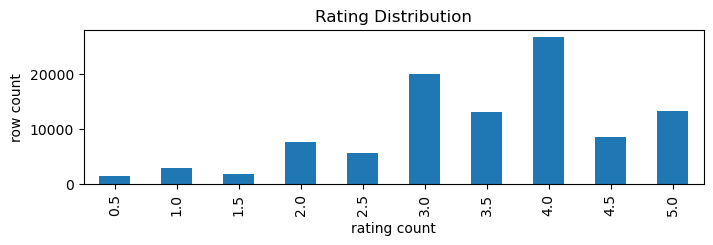

In [26]:
ratings_count.plot(kind="bar", figsize=(8, 2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [30]:
user_rating_count = ratings.groupby('userId').size().reset_index(name="user_rating_count")
print(user_rating_count)

     userId  user_rating_count
0         1                232
1         2                 29
2         3                 39
3         4                216
4         5                 44
..      ...                ...
605     606               1115
606     607                187
607     608                831
608     609                 37
609     610               1302

[610 rows x 2 columns]


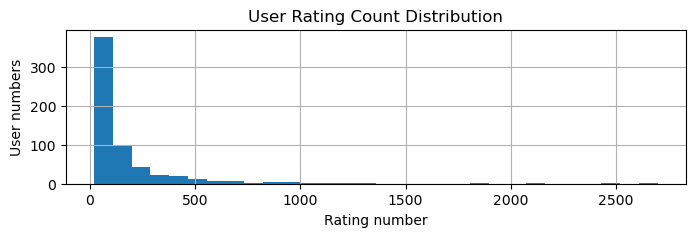

In [37]:
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,2))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating number")
plt.ylabel("User numbers")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [49]:
movie_rating_count = ratings.groupby('movieId').size().reset_index(name="movie_rating_count")
print(movie_rating_count)

      movieId  movie_rating_count
0           1                 215
1           2                 110
2           3                  52
3           4                   7
4           5                  49
...       ...                 ...
9719   193581                   1
9720   193583                   1
9721   193585                   1
9722   193587                   1
9723   193609                   1

[9724 rows x 2 columns]


In [51]:
# 영화별 평점 개수(movie_rating_count) + 영화(movies) 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

      movieId                               title  \
0           1                    Toy Story (1995)   
1           2                      Jumanji (1995)   
2           3             Grumpier Old Men (1995)   
3           4            Waiting to Exhale (1995)   
4           5  Father of the Bride Part II (1995)   
...       ...                                 ...   
7215   144976                Bone Tomahawk (2015)   
7216   146656                        Creed (2015)   
7217   146684       Cosmic Scrat-tastrophe (2015)   
7218   148238      A Very Murray Christmas (2015)   
7219   148626                The Big Short (2015)   

                                           genres  movie_rating_count  
0     Adventure|Animation|Children|Comedy|Fantasy                 215  
1                      Adventure|Children|Fantasy                 110  
2                                  Comedy|Romance                  52  
3                            Comedy|Drama|Romance                   7  
4  

In [54]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False) # sort_values : 값 기준 정렬
popular_movies.head(10)

,movieId,title,genres,movie_rating_count
300,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
263,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
245,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
490,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
1846,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
216,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
401,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
93,110,Braveheart (1995),Action|Drama|War,237
487,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
443,527,Schindler's List (1993),Drama|War,220


## 9. 영화별 평균 평점 Feature 생성

In [56]:
movie_rating_mean = ratings.groupby("movieId")["rating"].mean().reset_index(name="movie_rating_mean")
movie_rating_mean

,movieId,movie_rating_mean
0,1,3.920930
1,2,3.431818
2,3,3.259615
3,4,2.357143
4,5,3.071429
...,...,...
9719,193581,4.000000
9720,193583,3.500000
9721,193585,3.500000
9722,193587,3.500000


In [59]:
# movie_stats = 평점 개수 + 평균 평점 + 영화 정보
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId") # inner join 되기에 how 생략 가능
movie_stats.head()

,movieId,title,genres,movie_rating_count,movie_rating_mean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,110,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,52,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,7,2.357143
4,5,Father of the Bride Part II (1995),Comedy,49,3.071429


In [62]:
# 평점이 높은 영화 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
high_rating_movies.head(10)
# 결과에 평점 개수가 1인 애들이 위에 몇 나옴. 이러면 제대로 추천 불가.

,movieId,title,genres,movie_rating_count,movie_rating_mean
1178,1631,"Assignment, The (1997)",Action|Thriller,1,5.0
6415,84273,Zeitgeist: Moving Forward (2011),Documentary,1,5.0
3475,5241,Seems Like Old Times (1980),Comedy|Romance,1,5.0
6476,86721,Idiots and Angels (2008),Animation|Drama|Fantasy,1,5.0
5453,47736,"Chump at Oxford, A (1940)",Comedy,1,5.0
2584,3678,"Man with the Golden Arm, The (1955)",Drama,1,5.0
6098,70451,Max Manus (2008),Action|Drama|War,1,5.0
2222,3096,My Man Godfrey (1957),Comedy,1,5.0
4152,6818,Come and See (Idi i smotri) (1985),Drama|War,2,5.0
2213,3086,Babes in Toyland (1934),Children|Comedy|Fantasy|Musical,1,5.0


In [65]:
# 평점 개수가 많고[1순위] 평점이 높은 영화[2순위] 정렬
high_rating_movies2 = movie_stats.sort_values(["movie_rating_count", "movie_rating_mean"], ascending=False)
high_rating_movies2.head(10)
# 얘도 순서가 조금 애매함. 이래서 평점 개수와 평균을 이용한 공식으로 산출하는 거.

,movieId,title,genres,movie_rating_count,movie_rating_mean
300,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
263,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
245,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
490,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290
1846,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446
216,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076
401,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238,3.750000
93,110,Braveheart (1995),Action|Drama|War,237,4.031646
487,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224,3.970982
443,527,Schindler's List (1993),Drama|War,220,4.225000


In [74]:
# 기준 설정(1)
# 평가수(movie_rating_count)가 30개 이상인 영화를 기준
qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= 30]  # boolean indexing
print(qualified_movie)

      movieId                                              title  \
0           1                                   Toy Story (1995)   
1           2                                     Jumanji (1995)   
2           3                            Grumpier Old Men (1995)   
4           5                 Father of the Bride Part II (1995)   
5           6                                        Heat (1995)   
...       ...                                                ...   
7111   122882                          Mad Max: Fury Road (2015)   
7112   122886  Star Wars: Episode VII - The Force Awakens (2015)   
7166   134130                                Martian, The (2015)   
7172   134853                                  Inside Out (2015)   
7192   139385                                The Revenant (2015)   

                                           genres  movie_rating_count  \
0     Adventure|Animation|Children|Comedy|Fantasy                 215   
1                      Adventure|Chil

In [75]:
# 기준 설정(2)
# 분위수 0.75 => 25%, 상위 25%에 해당하는 영화만 출력
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.9)
# qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]
# print(qualified_movie)
# 아래 함수를 위해 이거 주석 처리함.

## 10. 인기 영화 추천 함수

In [76]:
def recommend_popular_movie(top_n):
    result = (
        qualified_movie.sort_values("movie_rating_mean", ascending=False).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ];

In [77]:
# 인기있는 영화 Top 10
recommend_popular_movie(10)

,movieId,title,movie_rating_count,movie_rating_mean
263,318,"Shawshank Redemption, The (1994)",317,4.429022
868,1204,Lawrence of Arabia (1962),45,4.300000
631,858,"Godfather, The (1972)",192,4.289062
2115,2959,Fight Club (1999),218,4.272936
937,1276,Cool Hand Luke (1967),57,4.271930
579,750,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041
657,904,Rear Window (1954),84,4.261905
884,1221,"Godfather: Part II, The (1974)",129,4.259690
5477,48516,"Departed, The (2006)",107,4.252336
876,1213,Goodfellas (1990),126,4.250000


## 11. 장르 데이터 이해

In [ ]:
여기 못봄

## 12. 장르 One-Hot Encoding

In [80]:
# str.get_dummies()
genre_feature = movies["genres"].str.get_dummies(sep="|")
print(genre_feature)

       (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                       0       0          1          1         1       1   
1                       0       0          1          0         1       0   
2                       0       0          0          0         0       1   
3                       0       0          0          0         0       1   
4                       0       0          0          0         0       1   
...                   ...     ...        ...        ...       ...     ...   
10324                   0       0          0          1         1       1   
10325                   0       0          0          0         0       1   
10326                   0       0          0          0         0       1   
10327                   0       0          0          0         0       0   
10328                   1       0          0          0         0       0   

       Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical

In [81]:
# movies 에 genre_feature 컬럼 추가 - concat
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_feature
    ],
    axis=1
)
print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 13. 코사인 유사도 불러오기

💥 유사도 행렬(Similarity Matrix) :: 